# 1C Sales prediction

## Part 0: Data processing

In [1]:
import numpy as np
import pandas as pd
import dateutil
import datetime as dt
from datetime import date
from pandarallel import pandarallel
import matplotlib.pyplot as plt
import seaborn as sns
import re
import gc
from tqdm.notebook import tqdm
import pickle

from itertools import permutations, product

import lightgbm as lgb

from lightgbm import LGBMRegressor
from lofo import LOFOImportance, FLOFOImportance, Dataset, plot_importance

from sklearn.metrics import (mean_squared_log_error, mean_squared_error,
                             mean_absolute_error)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

from sklearn.model_selection import train_test_split, KFold
import warnings

Pandarallel is needed to parse dates from the initial dataset a little faster:

In [2]:
pandarallel.initialize()

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


Reduce RAM usage. From https://www.kaggle.com/caesarlupum/ashrae-start-here-a-gentle-introduction:

In [3]:
## Function to reduce the DF size
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: print('Mem. usage decreased to {:5.2f} Mb ({:.1f}% reduction)'.format(end_mem, 100 * (start_mem - end_mem) / start_mem))
    return df

## Import and prepare data

In [4]:
train_df = pd.read_csv('data/sales_train.csv')
test_df = pd.read_csv('data/test.csv')
item_df = pd.read_csv('data/items.csv')
item_cat_df = pd.read_csv('data/item_categories.csv')
shop_df = pd.read_csv('data/shops.csv')

USD/RUB exchange rate taken from https://www.finam.ru/profile/forex/usd-rub/export/ :

In [5]:
exch_rate = pd.read_csv('data/exchange_rate.csv', sep=',', parse_dates=['<DATE>'])
exch_rate = exch_rate.drop(['<TICKER>', '<PER>', '<TIME>'], axis=1)
exch_rate = exch_rate.rename(columns={'<DATE>':'date', '<CLOSE>':'rate'})

Parsing dates (pandarallel function parallel_apply):

In [6]:
train_df['date'] = train_df['date'].parallel_apply(dateutil.parser.parse, dayfirst=True)

### Outliers:

There is an entry with negative price:

In [7]:
train_df.loc[train_df['item_price']<0, :]

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
484683,2013-05-15,4,32,2973,-1.0,1.0


Filling it with mean price of this particular item:

In [8]:
train_df.loc[train_df['item_price']<0, 'item_price'] = train_df.loc[
    train_df['item_id']==train_df.loc[train_df['item_price']<0,
                                      'item_id'].values[0], 'item_price'].mean()

Getting rid of some of the outliers:

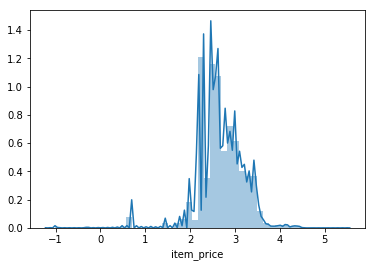

In [9]:
sns.distplot(np.log10(train_df['item_price']))

In [10]:
train_df = train_df.loc[train_df['item_price']<10**4.5, :]

/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in log10
  """Entry point for launching an IPython kernel.
/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/numpy/lib/histograms.py:839: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/numpy/lib/histograms.py:840: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)
/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/statsmodels/nonparametric/kde.py:447: RuntimeWarning: invalid value encountered in greater
  X = X[np.logical_and(X > clip[0], X < clip[1])] # won't work for two columns.
/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/statsmodels/nonparametric/kde.py:447: RuntimeWarning: invalid value encountered in less
  X = X[np.logical_and(X > clip[0], X < clip[1])] # won't work for two

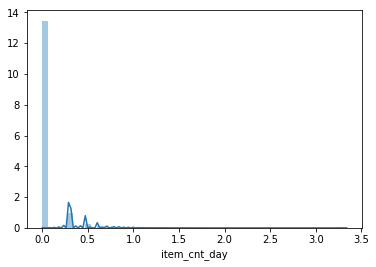

In [11]:
sns.distplot(np.log10(train_df['item_cnt_day']))

In [12]:
train_df = train_df.loc[train_df['item_cnt_day']<=10, :]

In [13]:
train_df.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
0,2013-01-02,0,59,22154,999.00,1.0
1,2013-01-03,0,25,2552,899.00,1.0
2,2013-01-05,0,25,2552,899.00,-1.0
3,2013-01-06,0,25,2554,1709.05,1.0
4,2013-01-15,0,25,2555,1099.00,1.0


### Adding zeros to the train set where no purchases have been done:

In [14]:
gr_date = train_df.groupby('date_block_num')

In [15]:
t_d = gr_date.apply(lambda x: product(*[[x.name], x['shop_id'].unique(), x['item_id'].unique()]))

In [16]:
all_vals = pd.DataFrame()
for t in tqdm(t_d.values):
    all_vals = pd.concat([all_vals, pd.DataFrame(t)], axis=0)

In [17]:
all_vals.columns = ['date_block_num', 'shop_id', 'item_id']
all_vals.head()

,date_block_num,shop_id,item_id
0,0,59,22154
1,0,59,2552
2,0,59,2554
3,0,59,2555
4,0,59,2564


Adding test shops/items @ last month:

In [18]:
test_df.head()

,ID,shop_id,item_id
0,0,5,5037
1,1,5,5320
2,2,5,5233
3,3,5,5232
4,4,5,5268


In [19]:
test_vals = pd.DataFrame()
test_vals['shop_id'] = test_df['shop_id'].copy()
test_vals['item_id'] = test_df['item_id'].copy()
test_vals['date_block_num'] = 34

In [20]:
all_vals = pd.concat([all_vals, test_vals], axis=0)

/home/anton/anaconda3/envs/my_env/lib/python3.7/site-packages/ipykernel_launcher.py:1: FutureWarning: Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.

  """Entry point for launching an IPython kernel.


### Items data

In [21]:
item_df.head(10)

,item_name,item_id,item_category_id
0,! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.) D,0,40
1,!ABBYY FineReader 12 Professional Edition Full...,1,76
2,***В ЛУЧАХ СЛАВЫ (UNV) D,2,40
3,***ГОЛУБАЯ ВОЛНА (Univ) D,3,40
4,***КОРОБКА (СТЕКЛО) D,4,40
5,***НОВЫЕ АМЕРИКАНСКИЕ ГРАФФИТИ (UNI) ...,5,40
6,***УДАР ПО ВОРОТАМ (UNI) D,6,40
7,***УДАР ПО ВОРОТАМ-2 (UNI) D,7,40
8,***ЧАЙ С МУССОЛИНИ D,8,40
9,***ШУГАРЛЭНДСКИЙ ЭКСПРЕСС (UNI) D,9,40


Borrowed from https://www.kaggle.com/kyakovlev/1st-place-solution-part-1-hands-on-data :

In [22]:
def name_correction(x):
    x = x.lower()
    x = x.partition('[')[0]
    x = x.partition('(')[0]
    x = re.sub('[^A-Za-z0-9А-Яа-я]+', ' ', x)
    x = x.replace('  ', ' ')
    x = x.strip()
    return x

In [23]:
item_df['item_name'] = item_df['item_name'].apply(name_correction)

In [24]:
item_df.head()

,item_name,item_id,item_category_id
0,во власти наваждения,0,40
1,abbyy finereader 12 professional edition full,1,76
2,в лучах славы,2,40
3,голубая волна,3,40
4,коробка,4,40


In [25]:
item_df['item_name'].unique().shape

(18121,)

In [26]:
item_df.shape

(22170, 3)

There are some repeating items in the dataset

### Item categories data

In [27]:
item_cat_df.head()

,item_category_name,item_category_id
0,PC - Гарнитуры/Наушники,0
1,Аксессуары - PS2,1
2,Аксессуары - PS3,2
3,Аксессуары - PS4,3
4,Аксессуары - PSP,4


In [28]:
item_cat_df['new_cats'] = (item_cat_df['item_category_name']
                           .str.split(' - ').apply(lambda x: x[0]))

In [29]:
item_cat_df['new_cats'].unique()

array(['PC', 'Аксессуары', 'Билеты (Цифра)', 'Доставка товара',
       'Игровые консоли', 'Игры', 'Игры Android', 'Игры MAC', 'Игры PC',
       'Карты оплаты (Кино, Музыка, Игры)', 'Карты оплаты', 'Кино',
       'Книги', 'Музыка', 'Подарки', 'Программы', 'Служебные',
       'Чистые носители (шпиль)', 'Чистые носители (штучные)',
       'Элементы питания'], dtype=object)

In [30]:
item_cat_df['new_subcats'] = (item_cat_df['item_category_name']
                           .str.split(' - ').apply(lambda x: x[-1]))

In [31]:
item_cat_df['new_subcats'].unique()

array(['Гарнитуры/Наушники', 'PS2', 'PS3', 'PS4', 'PSP', 'PSVita',
       'XBOX 360', 'XBOX ONE', 'Билеты (Цифра)', 'Доставка товара',
       'Прочие', 'Аксессуары для игр', 'Цифра', 'Дополнительные издания',
       'Коллекционные издания', 'Стандартные издания',
       'Карты оплаты (Кино, Музыка, Игры)', 'Live!', 'Live! (Цифра)',
       'PSN', 'Windows (Цифра)', 'Blu-Ray', 'Blu-Ray 3D', 'Blu-Ray 4K',
       'DVD', 'Коллекционное', 'Артбуки, энциклопедии', 'Аудиокниги',
       'Аудиокниги (Цифра)', 'Аудиокниги 1С', 'Бизнес литература',
       'Комиксы, манга', 'Компьютерная литература',
       'Методические материалы 1С', 'Открытки',
       'Познавательная литература', 'Путеводители',
       'Художественная литература', 'CD локального производства',
       'CD фирменного производства', 'MP3', 'Винил', 'Музыкальное видео',
       'Подарочные издания', 'Атрибутика', 'Гаджеты, роботы, спорт',
       'Мягкие игрушки', 'Настольные игры',
       'Настольные игры (компактные)', 'Открытки, на

### Shops data

In [32]:
shop_df.head()

,shop_name,shop_id
0,"!Якутск Орджоникидзе, 56 фран",0
1,"!Якутск ТЦ ""Центральный"" фран",1
2,"Адыгея ТЦ ""Мега""",2
3,"Балашиха ТРК ""Октябрь-Киномир""",3
4,"Волжский ТЦ ""Волга Молл""",4


Retrieving cities from the shop names:

In [33]:
shop_df['city'] = (shop_df['shop_name'].apply(name_correction)
                   .str.split(' ').apply(lambda x: x[0]))

In [34]:
shop_df.loc[shop_df['city']=='н', 'city'] = 'нижний_новгород'

In [35]:
shop_df['city'].unique()

array(['якутск', 'адыгея', 'балашиха', 'волжский', 'вологда', 'воронеж',
       'выездная', 'жуковский', 'интернет', 'казань', 'калуга', 'коломна',
       'красноярск', 'курск', 'москва', 'мытищи', 'нижний_новгород',
       'новосибирск', 'омск', 'ростовнадону', 'спб', 'самара', 'сергиев',
       'сургут', 'томск', 'тюмень', 'уфа', 'химки', 'цифровой', 'чехов',
       'ярославль'], dtype=object)

Retrieving shop types:

In [36]:
shop_df['shop_type'] = (shop_df['shop_name'].apply(name_correction)
                        .str.split(' ').apply(lambda x: x[1] if (len(x)>1) else 'other'))

In [37]:
shop_df['shop_type'].unique()

array(['орджоникидзе', 'тц', 'трк', 'трц', 'other', 'торговля', 'ул',
       'магазин', 'распродажа', 'мтрц', 'тк', 'новгород', 'посад',
       'склад'], dtype=object)

Renaming and merging some of the types:

In [38]:
shop_df.loc[(shop_df['shop_type']=='орджоникидзе')|
            (shop_df['shop_type']=='ул')|
           (shop_df['shop_type']=='распродажа')|
            (shop_df['shop_type']=='торговля')|
            (shop_df['shop_type']=='магазин'), 'shop_type'] = 'other'

In [39]:
shop_df.loc[(shop_df['shop_type']=='новгород')|
           (shop_df['shop_type']=='мтрц'), 'shop_type'] = 'трц'

In [40]:
shop_df.loc[(shop_df['shop_type']=='посад'),
            'shop_type'] = 'тц'

In [41]:
shop_df['shop_type'].unique()

array(['other', 'тц', 'трк', 'трц', 'тк', 'склад'], dtype=object)

### Merging everything together

In [42]:
item_df = pd.merge(item_df, item_cat_df[['item_category_id', 'new_cats', 'new_subcats']])

In [43]:
item_df = item_df.rename(columns={'new_cats': 'item_category',
                                    'new_subcats': 'item_subcategory'})

In [44]:
train_df = pd.merge(train_df, item_df[['item_name', 'item_id',
                                      'item_category', 'item_subcategory']])

In [45]:
train_df = pd.merge(train_df, shop_df[['city', 'shop_type', 'shop_id']])

In [46]:
train_df = pd.merge(train_df, exch_rate)

In [47]:
train_df.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category,item_subcategory,city,shop_type,rate
0,2013-01-02,0,59,22154,999.0,1.0,явление 2012,Кино,Blu-Ray,ярославль,тц,30.18
1,2013-01-02,0,59,2746,299.0,2.0,dead space 2,Игры PC,Стандартные издания,ярославль,тц,30.18
2,2013-01-02,0,59,2847,1699.0,1.0,disney история игрушек парк развлечений,Игры,XBOX 360,ярославль,тц,30.18
3,2013-01-02,0,59,2848,99.0,1.0,disney мир героев,Игры PC,Стандартные издания,ярославль,тц,30.18
4,2013-01-02,0,59,2854,449.0,1.0,disney храбрая сердцем,Игры PC,Стандартные издания,ярославль,тц,30.18


Price in USD:

In [48]:
train_df['price_usd'] = train_df['item_price'] / train_df['rate']

Revenue:

In [49]:
train_df['revenue'] = train_df['item_price'] * train_df['item_cnt_day']
train_df['revenue_usd'] = train_df['price_usd'] * train_df['item_cnt_day']

### Target variable:

In [50]:
gr_month = train_df.groupby(['shop_id', 'item_id', 'date_block_num'])

In [51]:
month_sum = gr_month.sum()

In [52]:
month_sum.shape

(1549122, 6)

In [53]:
month_sum.head()

item_price  item_cnt_day    rate   price_usd  \
shop_id item_id date_block_num                                                 
0       30      1                   2385.0          31.0  272.60   78.744539   
        31      1                   3038.0          11.0  212.17  100.234346   
        32      0                    884.0           6.0  120.53   29.337544   
                1                   1547.0          10.0  211.06   51.309233   
        33      0                   1041.0           3.0   90.60   34.470247   

                                revenue  revenue_usd  
shop_id item_id date_block_num                        
0       30      1                8215.0   271.611203  
        31      1                4774.0   157.860917  
        32      0                1326.0    43.949115  
                1                2210.0    73.280381  
        33      0                1041.0    34.470247

In [54]:
month_sum = month_sum.rename(columns={'item_cnt_day':'item_cnt_month'})

In [55]:
month_sum.head()

item_price  item_cnt_month    rate  \
shop_id item_id date_block_num                                       
0       30      1                   2385.0            31.0  272.60   
        31      1                   3038.0            11.0  212.17   
        32      0                    884.0             6.0  120.53   
                1                   1547.0            10.0  211.06   
        33      0                   1041.0             3.0   90.60   

                                 price_usd  revenue  revenue_usd  
shop_id item_id date_block_num                                    
0       30      1                78.744539   8215.0   271.611203  
        31      1               100.234346   4774.0   157.860917  
        32      0                29.337544   1326.0    43.949115  
                1                51.309233   2210.0    73.280381  
        33      0                34.470247   1041.0    34.470247

Clipping target variable according to the competition rules:

In [56]:
month_sum['item_cnt_month'] = month_sum['item_cnt_month'].clip(0, 20)

In [57]:
month_sum = month_sum.reset_index()[['shop_id', 'item_id',
                                     'item_cnt_month', 'date_block_num',
                                    'revenue', 'revenue_usd']]

Adding all the zero values:

In [58]:
month_sum = pd.merge(all_vals, month_sum,
                     on=['shop_id','item_id', 'date_block_num'],
                     how='left').fillna(0)

In [59]:
month_sum.head()

,date_block_num,item_id,shop_id,item_cnt_month,revenue,revenue_usd
0,0,22154,59,1.0,999.0,33.101392
1,0,2552,59,0.0,0.0,0.000000
2,0,2554,59,0.0,0.0,0.000000
3,0,2555,59,0.0,0.0,0.000000
4,0,2564,59,0.0,0.0,0.000000


In [60]:
month_sum.shape

(11126560, 6)

Merging with the shop and item datasets:

In [61]:
month_sum = reduce_mem_usage(month_sum)
shop_df = reduce_mem_usage(shop_df)
item_df = reduce_mem_usage(item_df)

Mem. usage decreased to 212.22 Mb (64.3% reduction)
Mem. usage decreased to  0.00 Mb (21.0% reduction)
Mem. usage decreased to  0.74 Mb (27.1% reduction)


In [62]:
month_sum = month_sum.merge(shop_df[['shop_id', 'city', 'shop_type']],
                            how='left', on=['shop_id'])

In [63]:
alles = month_sum.merge(item_df, how='left', on=['item_id'])

In [64]:
alles.head()

,date_block_num,item_id,shop_id,item_cnt_month,revenue,revenue_usd,city,shop_type,item_name,item_category_id,item_category,item_subcategory
0,0,22154,59,1.0,999.0,33.09375,ярославль,тц,явление 2012,37,Кино,Blu-Ray
1,0,2552,59,0.0,0.0,0.00000,ярославль,тц,deep purple the house of blue light lp,58,Музыка,Винил
2,0,2554,59,0.0,0.0,0.00000,ярославль,тц,deep purple who do you think we are lp,58,Музыка,Винил
3,0,2555,59,0.0,0.0,0.00000,ярославль,тц,deep purple 30 very best of 2cd,56,Музыка,CD фирменного производства
4,0,2564,59,0.0,0.0,0.00000,ярославль,тц,deep purple perihelion live in concert dvd,59,Музыка,Музыкальное видео


Average USD/RUB exchange rate:

In [65]:
exch_rate['month'] = exch_rate['date'].dt.month
exch_rate['year'] = exch_rate['date'].dt.year

In [66]:
temp_mean = exch_rate.groupby(['year', 'month']).mean().reset_index()

In [67]:
temp_mean['date_block_num'] = range(35)

In [68]:
temp_mean = reduce_mem_usage(temp_mean)

Mem. usage decreased to  0.00 Mb (75.8% reduction)


In [69]:
temp_mean.head()

,year,month,rate,date_block_num
0,2013,1,30.234375,0
1,2013,2,30.187500,1
2,2013,3,30.796875,2
3,2013,4,31.343750,3
4,2013,5,31.343750,4


In [70]:
alles = alles.merge(temp_mean, how='left', on=['date_block_num'])

## Feature engineering

### Lagging prices:

Borrowed from https://www.kaggle.com/dlarionov/feature-engineering-xgboost:

In [71]:
def lag_feature(df, lags, col):
    tmp = df[['date_block_num','shop_id','item_id',col]]
    for i in lags:
        shifted = tmp.copy()
        shifted.columns = ['date_block_num','shop_id','item_id', col+'_lag_'+str(i)]
        shifted['date_block_num'] += i
        df = pd.merge(df, shifted, on=['date_block_num','shop_id','item_id'], how='left')
    return df

In [72]:
gr = train_df.groupby(['item_id', 'shop_id', 'date_block_num'])

In [73]:
m_price = gr.mean()

In [74]:
m_price = m_price.rename(columns={'revenue': 'av_revenue', 'revenue_usd': 'av_revenue_usd', 
                                 'item_cnt_day': 'av_item_cnt_day', 'item_price': 'av_item_price',
                                 'price_usd': 'av_price_usd'})

In [75]:
m_price = m_price.drop(['rate'], axis=1)

Number of active days (where a purchase has been done) for a particular item-shop pair:

In [76]:
m_price['item_purchase_days'] = gr.count()['date']
m_price = m_price.reset_index()
m_price = reduce_mem_usage(m_price)

Mem. usage decreased to 25.12 Mb (76.4% reduction)


In [77]:
m_price.head()

,item_id,shop_id,date_block_num,av_item_price,av_item_cnt_day,av_price_usd,av_revenue,av_revenue_usd,item_purchase_days
0,0,54,20,58.0,1.0,1.553711,58.0,1.553711,1
1,1,55,15,4488.0,1.0,126.875000,4490.0,126.875000,2
2,1,55,18,4488.0,1.0,130.500000,4490.0,130.500000,1
3,1,55,19,4488.0,1.0,125.375000,4490.0,125.375000,1
4,1,55,20,4488.0,1.0,119.437500,4490.0,119.437500,1


Average number of items bought (on active days):

In [78]:
m_price['av_item_cnt_day'] /= m_price['item_purchase_days']

Mean item price over all shops and months and current deviation from its value:

In [79]:
m_group = m_price.groupby(['item_id'], as_index=False)['av_item_price'].mean()

In [80]:
m_group = m_group.rename(columns={'av_item_price': 'mean_price'})

In [81]:
m_price = pd.merge(all_vals, m_price,
                     on=['shop_id','item_id', 'date_block_num'],
                     how='left').fillna(0)

In [82]:
m_price = pd.merge(m_price, m_group, on=['item_id'], how='left')

In [83]:
m_price['price_dev'] = (m_price['av_item_price'] - m_price['mean_price']) / m_price['mean_price']

Lag everything:

In [84]:
m_price = lag_feature(m_price, [1, 2, 3, 6, 12], 'item_purchase_days')
m_price = lag_feature(m_price, [1, 2, 3, 6, 12], 'av_item_cnt_day')
m_price = lag_feature(m_price, [1, 2, 3], 'av_item_price')
m_price = lag_feature(m_price, [1, 2, 3], 'av_price_usd')
m_price = lag_feature(m_price, [1, 2, 3], 'price_dev')

In [85]:
m_price = lag_feature(m_price, [1, 2, 3], 'av_revenue')
m_price = lag_feature(m_price, [1, 2, 3], 'av_revenue_usd')

In [86]:
m_price.head()

,date_block_num,item_id,shop_id,av_item_price,av_item_cnt_day,av_price_usd,av_revenue,av_revenue_usd,item_purchase_days,mean_price,...,av_price_usd_lag_3,price_dev_lag_1,price_dev_lag_2,price_dev_lag_3,av_revenue_lag_1,av_revenue_lag_2,av_revenue_lag_3,av_revenue_usd_lag_1,av_revenue_usd_lag_2,av_revenue_usd_lag_3
0,0,22154,59,999.0,1.0,33.09375,999.0,33.09375,1.0,690.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,2552,59,0.0,0.0,0.00000,0.0,0.00000,0.0,943.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2554,59,0.0,0.0,0.00000,0.0,0.00000,0.0,1709.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,2555,59,0.0,0.0,0.00000,0.0,0.00000,0.0,1122.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,2564,59,0.0,0.0,0.00000,0.0,0.00000,0.0,341.25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


"Projected" values: silly linear extrapolation to the next month:

In [87]:
m_price['proj_av_revenue'] = 2 * (m_price['av_revenue_lag_1'] -
                           m_price['av_revenue_lag_2']) + m_price['av_revenue_lag_2']

m_price['proj_av_revenue_2'] = 3 * (m_price['av_revenue_lag_1'] - 
                             m_price['av_revenue_lag_3']) / 2 + m_price['av_revenue_lag_3']

In [88]:
m_price['proj_price'] = 2 * (m_price['av_item_price_lag_1'] - 
                             m_price['av_item_price_lag_2']) + m_price['av_item_price_lag_2']

m_price['proj_price_2'] = 3 * (m_price['av_item_price_lag_1'] - 
                               m_price['av_item_price_lag_3']) / 2 + m_price['av_item_price_lag_3']

In [89]:
cols = [c for c in m_price.columns if c not in ['item_cnt_day', 'rate',
                                                'av_item_price', 'av_price_usd',
                                                'revenue', 'revenue_usd', 'item_purchase_days',
                                                'av_item_cnt_day', 'price_dev',
                                               'av_revenue', 'av_revenue_usd']]

In [90]:
m_price = reduce_mem_usage(m_price.loc[:, cols])

Mem. usage decreased to 933.78 Mb (33.3% reduction)


In [91]:
alles = pd.merge(alles, m_price,
        on=['item_id', 'date_block_num', 'shop_id'], how='left')

In [92]:
del m_price
gc.collect()

141

### Lagging target variable:

In [93]:
alles = lag_feature(alles, [1, 2, 3, 6, 12], 'item_cnt_month')

Linear extrapolation to the next month:

In [94]:
alles['proj_item_cnt'] = 2 * (alles['item_cnt_month_lag_1'] - 
                              alles['item_cnt_month_lag_2']) + alles['item_cnt_month_lag_2']

alles['proj_item_cnt_2'] = 3 * (alles['item_cnt_month_lag_1'] -
                                alles['item_cnt_month_lag_3']) / 2 + alles['item_cnt_month_lag_3']

alles['proj_item_cnt_12'] = 12 * (alles['item_cnt_month_lag_1'] - 
                                  alles['item_cnt_month_lag_12']) / 11 + alles['item_cnt_month_lag_12']

Averaging the values based on the extrapolation over 1, 2, and 11 months:

In [95]:
alles['mean_proj_item_cnt'] = np.mean([alles['proj_item_cnt'],
                                       alles['proj_item_cnt_2'], alles['proj_item_cnt_12']], axis=0)

### Lagging revenues:

In [96]:
alles = lag_feature(alles, [1, 2, 3, 6, 12], 'revenue')
alles = lag_feature(alles, [1, 2, 3, 6, 12], 'revenue_usd')

Linear extrapolation:

In [97]:
alles['proj_monthly_revenue'] = 2 * (alles['revenue_lag_1'] - 
                                     alles['revenue_lag_2']) + alles['revenue_lag_2']

alles['proj_monthly_revenue_2'] = 3 * (alles['revenue_lag_1'] - 
                                       alles['revenue_lag_3']) / 2 + alles['revenue_lag_3']

alles['proj_monthly_revenue_12'] = 12 * (alles['revenue_lag_1'] - 
                                         alles['revenue_lag_12']) / 11 + alles['revenue_lag_12']

Averaging the extrapolated values:

In [98]:
alles['mean_proj_revenue'] = np.mean([alles['proj_monthly_revenue'],
                                       alles['proj_monthly_revenue_2'],
                                      alles['proj_monthly_revenue_12']], axis=0)

In [99]:
alles = alles.drop(['revenue', 'revenue_usd'], axis=1)

### Shop purchases per month (independent of the item_id):

In [100]:
gr_shop = train_df.groupby(['shop_id', 'date_block_num'])

In [101]:
pdf = pd.merge(all_vals, gr_shop.count()['date'], on=['shop_id', 'date_block_num'], how='left')

In [102]:
pdf = pdf.rename(columns={'date':'purchases_per_month'})[['date_block_num',
                                                         'shop_id',
                                                          'purchases_per_month']].drop_duplicates()

In [103]:
tmp = pdf[['date_block_num','shop_id', 'purchases_per_month']]
shifted = tmp.copy()
shifted.columns = ['date_block_num','shop_id', 'purchases_per_month'+'_lag_'+str(1)]
shifted['date_block_num'] += 1
pdf = pd.merge(pdf, shifted, on=['date_block_num','shop_id'], how='left')

In [104]:
pdf = reduce_mem_usage(pdf)

Mem. usage decreased to  0.02 Mb (65.0% reduction)


In [105]:
pdf = pdf.drop(['purchases_per_month'], axis=1)

In [106]:
alles = pd.merge(alles, pdf, on=['shop_id', 'date_block_num'], how='left')

### Shop active months:

In [107]:
cc_df = pd.DataFrame(gr_shop.mean().groupby('shop_id').cumcount(), columns=['active_months'])
cc_df = cc_df.reset_index()

In [108]:
cc_df = pd.merge(all_vals[['date_block_num', 'shop_id']], cc_df,
                 on=['date_block_num', 'shop_id'], how='left').drop_duplicates()

In [109]:
tmp = cc_df[['date_block_num','shop_id', 'active_months']]
for i in [1]:
    shifted = tmp.copy()
    shifted.columns = ['date_block_num','shop_id', 'active_months'+'_lag_'+str(i)]
    shifted['date_block_num'] += i
    cc_df = pd.merge(cc_df, shifted, on=['date_block_num','shop_id'], how='left')

In [110]:
cc_df = cc_df.drop(['active_months'], axis=1)

In [111]:
for i in [1]:
    cc_df['active_months_lag_'+str(i)] += i
    cc_df['active_months_lag_'+str(i)] = cc_df['active_months_lag_'+str(i)].fillna(0).astype('int')

In [112]:
cc_df = reduce_mem_usage(cc_df)

Mem. usage decreased to  0.02 Mb (65.6% reduction)


In [113]:
alles = pd.merge(alles, cc_df, on=['shop_id', 'date_block_num'], how='left')

### Item active months:

In [114]:
gr_item = train_df.groupby(['item_id', 'date_block_num'])

In [115]:
cc_df = pd.DataFrame(gr_item.mean().groupby('item_id').cumcount(), columns=['item_active_months'])
cc_df = cc_df.reset_index()

In [116]:
cc_df = pd.merge(all_vals[['date_block_num', 'item_id']], cc_df,
                 on=['date_block_num', 'item_id'], how='left').drop_duplicates()

In [117]:
tmp = cc_df[['date_block_num','item_id', 'item_active_months']]
for i in [1]:
    shifted = tmp.copy()
    shifted.columns = ['date_block_num','item_id', 'item_active_months'+'_lag_'+str(i)]
    shifted['date_block_num'] += i
    cc_df = pd.merge(cc_df, shifted, on=['date_block_num','item_id'], how='left')

In [118]:
cc_df = cc_df.drop(['item_active_months'], axis=1)

In [119]:
for i in [1]:
    cc_df['item_active_months_lag_'+str(i)] += i
    cc_df['item_active_months_lag_'+str(i)] = cc_df['item_active_months_lag_'+str(i)].fillna(0).astype('int')

In [120]:
cc_df = reduce_mem_usage(cc_df)

Mem. usage decreased to  2.73 Mb (62.5% reduction)


In [121]:
alles = pd.merge(alles, cc_df, on=['item_id', 'date_block_num'], how='left')

### Shop+item active months:

In [122]:
cc_df = pd.DataFrame(gr.mean().groupby(['shop_id','item_id']).cumcount(), columns=['shop_item_active_months'])
cc_df = cc_df.reset_index()

In [123]:
cc_df = pd.merge(all_vals, cc_df,
                 on=['date_block_num', 'shop_id', 'item_id'], how='left').drop_duplicates()

In [124]:
cc_df = lag_feature(cc_df, [1], 'shop_item_active_months')

In [125]:
for i in [1]:
    cc_df['shop_item_active_months_lag_'+str(i)] += i
    cc_df['shop_item_active_months_lag_'+str(i)] = cc_df['shop_item_active_months_lag_'
                                                         +str(i)].fillna(0).astype('int')

In [126]:
cc_df = cc_df.drop(['shop_item_active_months'], axis=1)

In [127]:
cc_df = reduce_mem_usage(cc_df)

Mem. usage decreased to 137.94 Mb (67.5% reduction)


In [128]:
alles = pd.merge(alles, cc_df, on=['item_id', 'shop_id', 'date_block_num'], how='left')

### Cumulative shop revenue:

In [129]:
cum_revs = gr_shop.mean()

In [130]:
cum_revs = cum_revs[['revenue', 'revenue_usd']]

In [131]:
cum_revs = cum_revs.reset_index()

In [132]:
cum_revs = pd.merge(all_vals[['shop_id', 'date_block_num']],
         cum_revs, on=['shop_id', 'date_block_num'], how='left').drop_duplicates()

In [133]:
cum_revs['c_shop_revenue_usd'] = cum_revs.groupby('shop_id')['revenue_usd'].cumsum().values
cum_revs['c_shop_revenue'] = cum_revs.groupby('shop_id')['revenue'].cumsum().values

In [134]:
tmp = cum_revs[['date_block_num','shop_id', 'c_shop_revenue']]
shifted = tmp.copy()
shifted.columns = ['date_block_num','shop_id', 'c_shop_revenue'+'_lag_'+str(1)]
shifted['date_block_num'] += 1
cum_revs = pd.merge(cum_revs, shifted, on=['date_block_num','shop_id'], how='left')

In [135]:
tmp = cum_revs[['date_block_num','shop_id', 'c_shop_revenue_usd']]
shifted = tmp.copy()
shifted.columns = ['date_block_num','shop_id', 'c_shop_revenue_usd'+'_lag_'+str(1)]
shifted['date_block_num'] += 1
cum_revs = pd.merge(cum_revs, shifted, on=['date_block_num','shop_id'], how='left')

In [136]:
cum_revs = reduce_mem_usage(cum_revs)

Mem. usage decreased to  0.03 Mb (69.4% reduction)


In [137]:
alles = pd.merge(alles, cum_revs[['shop_id', 'date_block_num',
                                  'c_shop_revenue_lag_1', 'c_shop_revenue_usd_lag_1']],
                                   on=['shop_id', 'date_block_num'], how='left')

### Cumulative shop revenue based on a particular item:

In [138]:
cum_revs = gr.mean()

In [139]:
cum_revs = cum_revs[['revenue', 'revenue_usd']]

In [140]:
cum_revs = cum_revs.reset_index()

In [141]:
cum_revs = pd.merge(all_vals, cum_revs, on=['shop_id', 'date_block_num', 'item_id'], how='left')

In [142]:
cum_revs['revenue'] = cum_revs['revenue'].fillna(0)
cum_revs['revenue_usd'] = cum_revs['revenue_usd'].fillna(0)

In [143]:
cum_revs['c_revenue_usd'] = cum_revs.groupby('shop_id')['revenue_usd'].cumsum().values
cum_revs['c_revenue'] = cum_revs.groupby('shop_id')['revenue'].cumsum().values

In [144]:
cum_revs = lag_feature(cum_revs, [1], 'c_revenue')

In [145]:
cum_revs = lag_feature(cum_revs, [1], 'c_revenue_usd')

In [146]:
cum_revs = reduce_mem_usage(cum_revs)

Mem. usage decreased to 360.78 Mb (57.5% reduction)


In [147]:
alles = pd.merge(alles, cum_revs[['shop_id', 'date_block_num', 'item_id',
                                  'c_revenue_lag_1', 'c_revenue_usd_lag_1']],
                                   on=['shop_id', 'date_block_num', 'item_id'], how='left')

### Other mean values:

In [148]:
month_sum.head()

,date_block_num,item_id,shop_id,item_cnt_month,revenue,revenue_usd,city,shop_type
0,0,22154,59,1.0,999.0,33.09375,ярославль,тц
1,0,2552,59,0.0,0.0,0.00000,ярославль,тц
2,0,2554,59,0.0,0.0,0.00000,ярославль,тц
3,0,2555,59,0.0,0.0,0.00000,ярославль,тц
4,0,2564,59,0.0,0.0,0.00000,ярославль,тц


Mean over __all shops and all items__ (fixed month):

In [149]:
group = month_sum.groupby(['date_block_num'])
gr_df = group.mean()
gr_df = gr_df.rename(columns={'item_cnt_month':'av_month'}).reset_index()

In [150]:
tmp = gr_df[['date_block_num', 'av_month']]
shifted = tmp.copy()
shifted.columns = ['date_block_num', 'av_month'+'_lag_'+str(1)]
shifted['date_block_num'] += 1
gr_df = pd.merge(gr_df, shifted, on=['date_block_num'], how='left')

In [151]:
gr_df = reduce_mem_usage(gr_df)

Mem. usage decreased to  0.00 Mb (50.0% reduction)


In [152]:
alles = pd.merge(alles, gr_df[['av_month_lag_1', 'date_block_num']], on=['date_block_num'], how='left')

Mean over __all shops__ (fixed item and month):

In [153]:
group = month_sum.groupby(['date_block_num', 'item_id'])
gr_df = group.mean()
gr_df = gr_df.rename(columns={'item_cnt_month':'av_month_item'}).reset_index()

In [154]:
tmp = gr_df[['date_block_num', 'item_id', 'av_month_item']]
shifted = tmp.copy()
shifted.columns = ['date_block_num', 'item_id', 'av_month_item'+'_lag_'+str(1)]
shifted['date_block_num'] += 1
gr_df = pd.merge(gr_df, shifted, on=['date_block_num', 'item_id'], how='left')

In [155]:
gr_df = reduce_mem_usage(gr_df)

Mem. usage decreased to  5.24 Mb (45.2% reduction)


In [156]:
alles = pd.merge(alles, gr_df[['av_month_item_lag_1', 'date_block_num', 'item_id']],
                 on=['date_block_num', 'item_id'], how='left')

Mean over __all items__ (fixed month and shop):

In [157]:
group = month_sum.groupby(['date_block_num', 'shop_id'])
gr_df = group.mean()
gr_df = gr_df.rename(columns={'item_cnt_month':'av_month_shop'}).reset_index()

In [158]:
tmp = gr_df[['date_block_num', 'shop_id', 'av_month_shop']]
shifted = tmp.copy()
shifted.columns = ['date_block_num', 'shop_id', 'av_month_shop'+'_lag_'+str(1)]
shifted['date_block_num'] += 1
gr_df = pd.merge(gr_df, shifted, on=['date_block_num', 'shop_id'], how='left')

In [159]:
gr_df = reduce_mem_usage(gr_df)

Mem. usage decreased to  0.03 Mb (52.4% reduction)


In [160]:
alles = pd.merge(alles, gr_df[['av_month_shop_lag_1', 'date_block_num', 'shop_id']],
                 on=['date_block_num', 'shop_id'], how='left')

Mean over __fixed category id and month__:

In [161]:
month_cat = pd.merge(month_sum, item_df)

In [162]:
group = month_cat.groupby(['date_block_num', 'item_category_id'])
gr_df = group.mean()
gr_df = gr_df.rename(columns={'item_cnt_month':'av_month_cat'}).reset_index()

In [163]:
tmp = gr_df[['date_block_num', 'item_category_id', 'av_month_cat']]
shifted = tmp.copy()
shifted.columns = ['date_block_num', 'item_category_id', 'av_month_cat'+'_lag_'+str(1)]
shifted['date_block_num'] += 1
gr_df = pd.merge(gr_df, shifted, on=['date_block_num', 'item_category_id'], how='left')

In [164]:
gr_df = reduce_mem_usage(gr_df)

Mem. usage decreased to  0.05 Mb (52.0% reduction)


In [165]:
alles = pd.merge(alles, gr_df[['av_month_cat_lag_1', 'date_block_num', 'item_category_id']],
                 on=['date_block_num', 'item_category_id'], how='left')

Mean over __fixed subcategory and month__:

In [166]:
group = month_cat.groupby(['date_block_num', 'item_subcategory'])
gr_df = group.mean()
gr_df = gr_df.rename(columns={'item_cnt_month':'av_month_subcat'}).reset_index()

In [167]:
tmp = gr_df[['date_block_num', 'item_subcategory', 'av_month_subcat']]
shifted = tmp.copy()
shifted.columns = ['date_block_num', 'item_subcategory', 'av_month_subcat'+'_lag_'+str(1)]
shifted['date_block_num'] += 1
gr_df = pd.merge(gr_df, shifted, on=['date_block_num', 'item_subcategory'], how='left')

In [168]:
gr_df = reduce_mem_usage(gr_df)

Mem. usage decreased to  0.05 Mb (46.6% reduction)


In [169]:
alles = pd.merge(alles, gr_df[['av_month_subcat_lag_1', 'date_block_num', 'item_subcategory']],
                 on=['date_block_num', 'item_subcategory'], how='left')

Mean over __all months__ (fixed shop/item pairs):

In [170]:
group = month_sum.groupby(['shop_id', 'item_id'])
gr_df = group.mean()
gr_df = gr_df.rename(columns={'item_cnt_month':'av_shop_item'}).reset_index()

In [171]:
gr_df = reduce_mem_usage(gr_df)

Mem. usage decreased to 14.28 Mb (59.4% reduction)


In [172]:
alles = pd.merge(alles, gr_df[['av_shop_item', 'shop_id', 'item_id']],
                 on=['shop_id', 'item_id'], how='left')

### First sales:

In [173]:
alles['first_sale'] = (alles['date_block_num'] -
                       alles.groupby(['item_id','shop_id'])['date_block_num'].transform('min'))
alles['item_first_sale'] = (alles['date_block_num'] -
                            alles.groupby('item_id')['date_block_num'].transform('min'))
alles['shop_first_sale'] = (alles['date_block_num'] -
                            alles.groupby('shop_id')['date_block_num'].transform('min'))

In [174]:
del train_df, month_sum, cum_revs, month_cat, shifted, tmp, gr_df, cc_df
gc.collect()

292

In [175]:
with open('data/alles_final.pkl', 'wb') as handle:
    pickle.dump(alles, handle)